In [1]:
from pathlib import Path

import torch
from diffusers import Flux2KleinKVPipeline, PipelineQuantizationConfig, TorchAoConfig
from helper import root_dir
from torchao.quantization import (
    Int8WeightOnlyConfig,
    PerGroup,
)


device = "mps"
dtype = torch.bfloat16
model_path = Path.home() / ".omlx/models/ImageGen/FLUX.2-klein-9b-kv"
output_dir = root_dir / "outputs"


pipeline_quant_config = PipelineQuantizationConfig(
    # quant_mapping={"transformer": TorchAoConfig(Int8WeightOnlyConfig(granularity=PerGroup(), version=2))}
    quant_mapping={
        "transformer": TorchAoConfig(
            Int8WeightOnlyConfig(granularity=PerGroup(64), version=2)
        )
    }
)

/Users/houzhi/Projects/quantize-to-mlx/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
W0422 18:19:13.687000 53245 torch/distributed/elastic/multiprocessing/redirects.py:35] NOTE: Redirects are currently not supported in MacOs.
W0422 18:19:13.718000 53245 torch/utils/_pytree.py:630] <enum 'KernelPreference'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.
W0422 18:19:13.742000 53245 torch/utils/_pytree.py:630] <enum 'ScaleCalculationMode'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.
Unable to import `torc

In [2]:
pipe = Flux2KleinKVPipeline.from_pretrained(
    model_path,
    quantization_config=pipeline_quant_config,
    torch_dtype=dtype,
    device_map=device,
)

Loading pipeline components...: 100%|██████████| 5/5 [00:23<00:00,  4.72s/it]


In [3]:
images = pipe(
    prompt="A puffin standing on a cliff",
    height=1024,
    width=1024,
    num_inference_steps=4,
    generator=torch.Generator(device=device).manual_seed(0),
)
images.images[0].save(output_dir / "puffin-torchao.png")
images

100%|██████████| 4/4 [00:34<00:00,  8.59s/it]


Flux2PipelineOutput(images=[<PIL.Image.Image image mode=RGB size=1024x1024 at 0x128B0C050>])

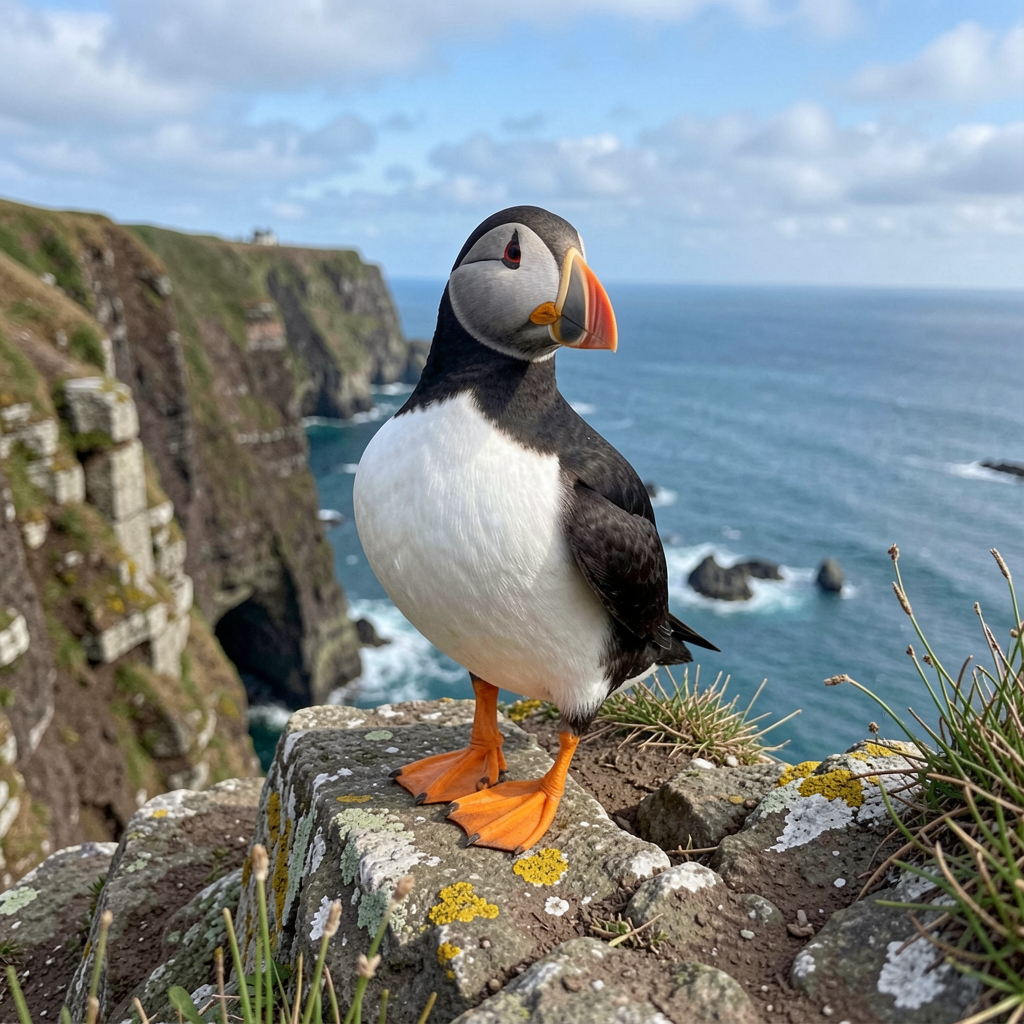

In [6]:
images.images[0]